# Лабораторная работа 14 — Персептрон

**Цель работы:** изучить модели персептрона и многослойного персептрона (MLP), исследовать влияние архитектуры сети на качество классификации жанров GTZAN.

## Теоретическое введение

### Персептрон

**Персептрон** — простейшая модель искусственного нейрона. Он вычисляет взвешенную сумму входов и применяет пороговую функцию активации:

$$\hat{y} = f\left(\sum_{i=1}^{n} w_i x_i + b\right)$$

Персептрон — **линейный классификатор**, способный разделять только линейно разделимые классы. Обучается правилом Розенблатта: если классификация неверна, веса обновляются в сторону правильного ответа.

### Многослойный персептрон (MLP)

**MLP** (Multi-Layer Perceptron) — нейронная сеть из нескольких слоёв нейронов:
- **Входной слой** — принимает признаки
- **Скрытые слои** — нелинейные преобразования (ReLU, tanh, sigmoid)
- **Выходной слой** — softmax для мультиклассовой классификации

MLP обучается алгоритмом **обратного распространения ошибки** (backpropagation) — вычисление градиентов функции потерь по весам с помощью цепного правила дифференцирования.

Доказано, что MLP с **одним скрытым слоем** может аппроксимировать любую непрерывную функцию (теорема Цыбенко). На практике более глубокие сети обучаются эффективнее.

### Гиперпараметры MLP

- `hidden_layer_sizes` — число слоёв и нейронов: (100,) = 1 слой по 100 нейронов
- `activation` — функция активации (relu, tanh, logistic)
- `learning_rate_init` — начальный шаг обучения
- `max_iter` — максимальное число эпох

## 1. Загрузка и предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../datasets/gtzan/features_30_sec.csv')
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Датасет: {X.shape[0]} сэмплов, {X.shape[1]} признаков, {len(le.classes_)} классов')
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Датасет: 1000 сэмплов, 57 признаков, 10 классов
Train: 800, Test: 200


## 2. Персептрон (линейный классификатор)

Простой персептрон без скрытых слоёв — по сути линейный классификатор. Он может работать плохо на сложных мультиклассовых задачах.

In [2]:
perceptron = Perceptron(max_iter=1000, eta0=0.01, random_state=42)
perceptron.fit(X_train, y_train)

acc_perc = accuracy_score(y_test, perceptron.predict(X_test))
print(f'Perceptron accuracy: {acc_perc:.4f}')
print()
print(classification_report(y_test, perceptron.predict(X_test), target_names=le.classes_))

Perceptron accuracy: 0.6000

              precision    recall  f1-score   support

       blues       0.43      0.50      0.47        20
   classical       0.81      0.85      0.83        20
     country       0.55      0.55      0.55        20
       disco       0.33      0.25      0.29        20
      hiphop       0.80      0.60      0.69        20
        jazz       0.62      0.80      0.70        20
       metal       0.74      0.70      0.72        20
         pop       0.70      0.70      0.70        20
      reggae       0.53      0.80      0.64        20
        rock       0.45      0.25      0.32        20

    accuracy                           0.60       200
   macro avg       0.60      0.60      0.59       200
weighted avg       0.60      0.60      0.59       200



## 3. Многослойный персептрон (MLP)

Исследуем влияние архитектуры (число скрытых слоёв и нейронов) на качество классификации.

In [3]:
architectures = {
    '(50,)': (50,),
    '(100,)': (100,),
    '(200,)': (200,),
    '(100, 50)': (100, 50),
    '(200, 100)': (200, 100),
    '(200, 100, 50)': (200, 100, 50),
}

mlp_results = {}
mlp_models = {}

for name, hidden in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden, max_iter=500,
        learning_rate_init=0.001, random_state=42,
        early_stopping=True, validation_fraction=0.15
    )
    mlp.fit(X_train, y_train)
    acc = accuracy_score(y_test, mlp.predict(X_test))
    mlp_results[name] = acc
    mlp_models[name] = mlp
    print(f'MLP {name:16s}: accuracy = {acc:.4f} (эпох: {mlp.n_iter_})')

MLP (50,)           : accuracy = 0.7200 (эпох: 85)


MLP (100,)          : accuracy = 0.7200 (эпох: 86)
MLP (200,)          : accuracy = 0.7300 (эпох: 43)


MLP (100, 50)       : accuracy = 0.7000 (эпох: 52)
MLP (200, 100)      : accuracy = 0.7350 (эпох: 47)


MLP (200, 100, 50)  : accuracy = 0.7450 (эпох: 48)


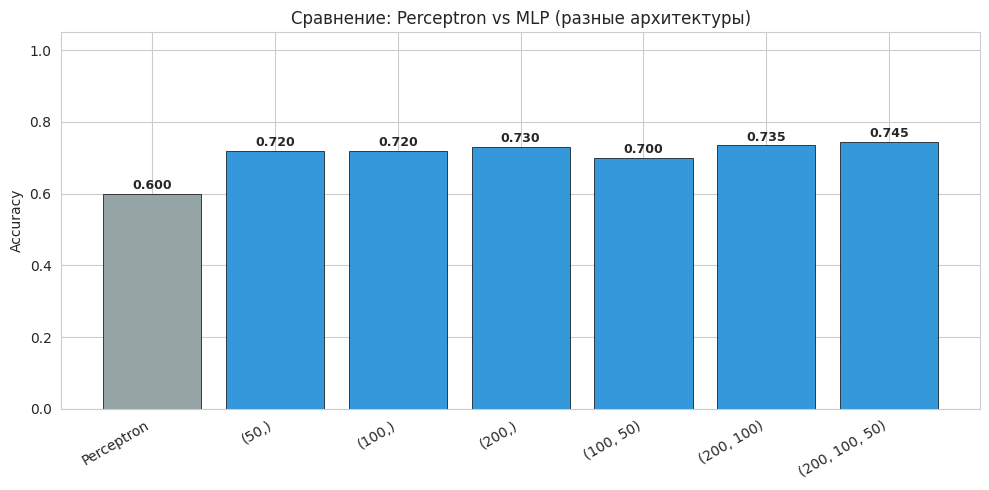

In [4]:
# Сравнение архитектур
fig, ax = plt.subplots(figsize=(10, 5))

all_names = ['Perceptron'] + list(mlp_results.keys())
all_accs = [acc_perc] + list(mlp_results.values())
colors = ['#95a5a6'] + ['#3498db'] * len(mlp_results)

bars = ax.bar(all_names, all_accs, color=colors, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение: Perceptron vs MLP (разные архитектуры)')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Confusion matrix и classification report

Оценим лучшую MLP-модель подробно.

=== Лучшая архитектура: MLP (200, 100, 50) ===
              precision    recall  f1-score   support

       blues       0.71      0.85      0.77        20
   classical       0.95      0.95      0.95        20
     country       0.84      0.80      0.82        20
       disco       0.65      0.55      0.59        20
      hiphop       0.71      0.85      0.77        20
        jazz       0.67      0.80      0.73        20
       metal       0.93      0.70      0.80        20
         pop       0.80      0.80      0.80        20
      reggae       0.68      0.65      0.67        20
        rock       0.56      0.50      0.53        20

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200



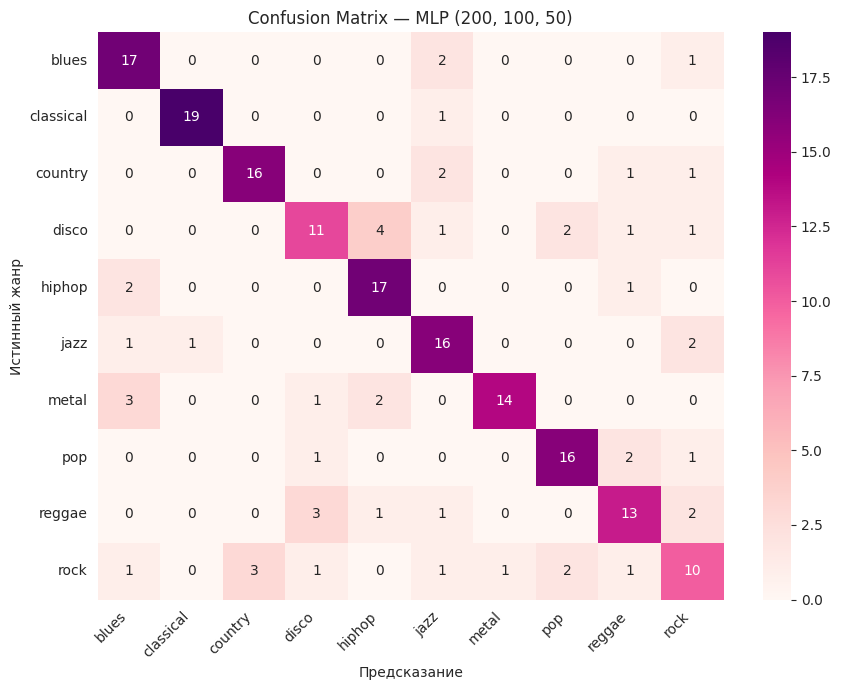

In [5]:
best_arch = max(mlp_results, key=mlp_results.get)
best_mlp = mlp_models[best_arch]
y_pred_best = best_mlp.predict(X_test)

print(f'=== Лучшая архитектура: MLP {best_arch} ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный жанр')
ax.set_title(f'Confusion Matrix — MLP {best_arch}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. ROC-кривые

Micro-average ROC для Perceptron и лучшей MLP.

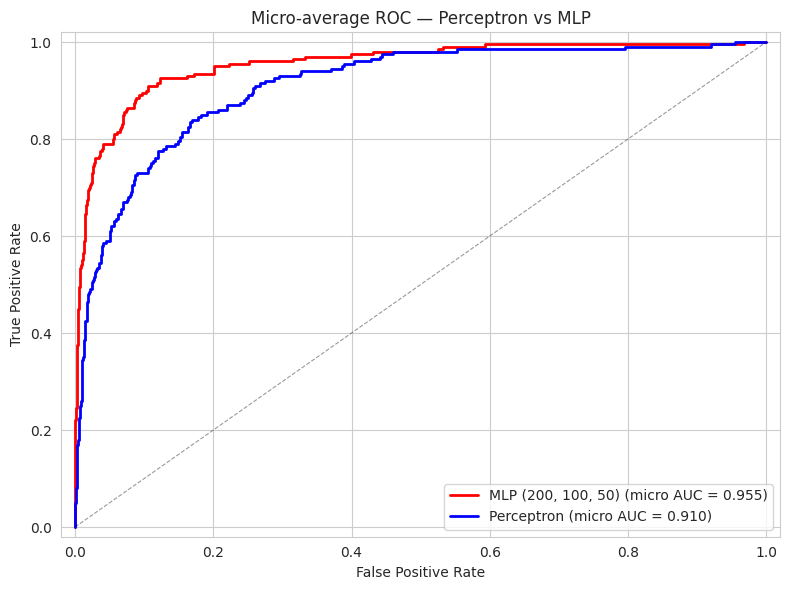

In [6]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(8, 6))

# MLP ROC
y_proba_mlp = best_mlp.predict_proba(X_test)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_bin.ravel(), y_proba_mlp.ravel())
auc_mlp = auc(fpr_mlp, tpr_mlp)
ax.plot(fpr_mlp, tpr_mlp, 'r-', linewidth=2,
        label=f'MLP {best_arch} (micro AUC = {auc_mlp:.3f})')

# Perceptron ROC (decision_function)
y_scores_perc = perceptron.decision_function(X_test)
# Normalize for multi-class
from scipy.special import softmax
y_proba_perc = softmax(y_scores_perc, axis=1)
fpr_perc, tpr_perc, _ = roc_curve(y_test_bin.ravel(), y_proba_perc.ravel())
auc_perc = auc(fpr_perc, tpr_perc)
ax.plot(fpr_perc, tpr_perc, 'b-', linewidth=2,
        label=f'Perceptron (micro AUC = {auc_perc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Micro-average ROC — Perceptron vs MLP')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

## 6. Кривая обучения (loss по эпохам)

MLP отслеживает функцию потерь на каждой эпохе. Визуализация кривой обучения помогает понять, достаточно ли эпох и нет ли переобучения.

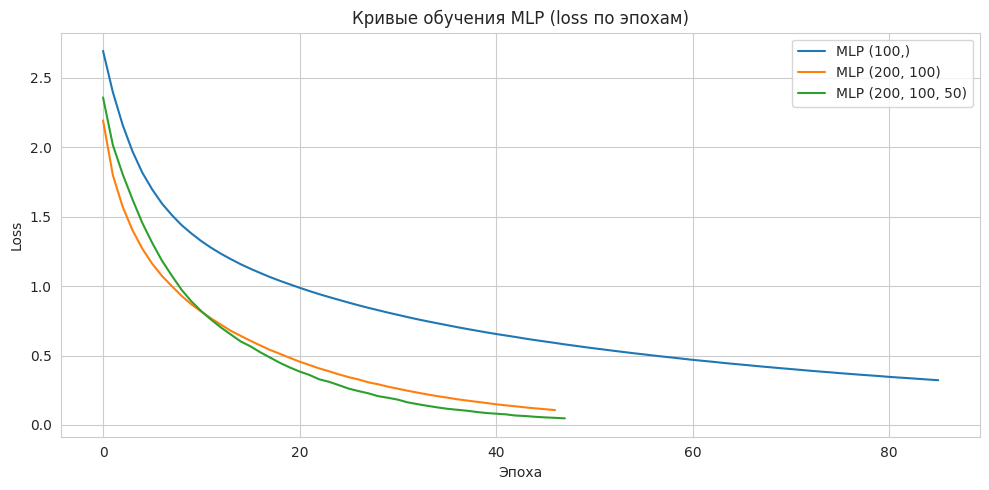

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

for name in ['(100,)', '(200, 100)', '(200, 100, 50)']:
    model = mlp_models[name]
    ax.plot(model.loss_curve_, linewidth=1.5, label=f'MLP {name}')

ax.set_xlabel('Эпоха')
ax.set_ylabel('Loss')
ax.set_title('Кривые обучения MLP (loss по эпохам)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Кросс-валидация

Perceptron      : 0.6150 ± 0.0405


MLP (100,)      : 0.6740 ± 0.0549


MLP (200,100)   : 0.6940 ± 0.0371


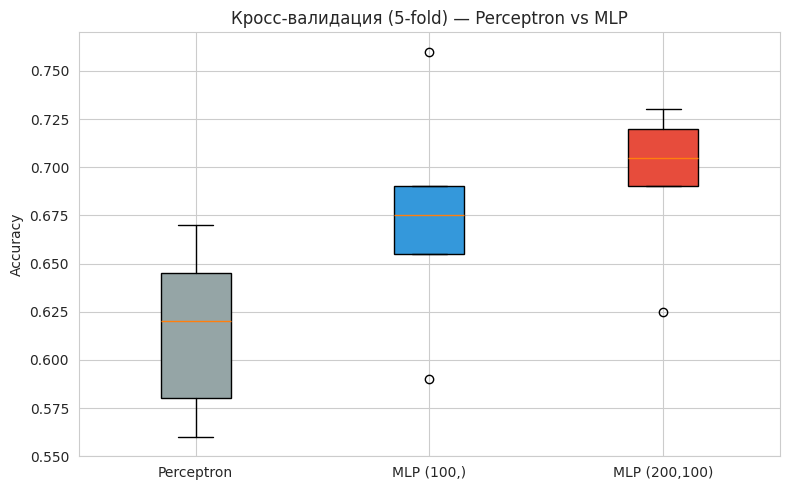

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Perceptron': Perceptron(max_iter=1000, eta0=0.01, random_state=42),
    'MLP (100,)': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, early_stopping=True),
    'MLP (200,100)': MLPClassifier(hidden_layer_sizes=(200, 100), max_iter=500, random_state=42, early_stopping=True),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:16s}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([cv_results[n] for n in cv_results],
                labels=list(cv_results.keys()), patch_artist=True)
colors_box = ['#95a5a6', '#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.set_ylabel('Accuracy')
ax.set_title('Кросс-валидация (5-fold) — Perceptron vs MLP')
plt.tight_layout()
plt.show()

## Выводы

1. **Простой персептрон** (линейный классификатор) показывает ограниченное качество на задаче классификации жанров, так как классы не являются линейно разделимыми.

2. **Многослойный персептрон** (MLP) значительно превосходит однослойный персептрон благодаря нелинейным преобразованиям в скрытых слоях.

3. **Увеличение числа нейронов и слоёв** улучшает accuracy до определённого предела, после которого начинается переобучение (loss уменьшается, но accuracy на тесте не растёт).

4. **Early stopping** предотвращает переобучение, останавливая обучение при отсутствии улучшений на валидационной выборке.

5. **Кривые обучения** показывают, что более глубокие сети сходятся быстрее, но могут переобучаться без регуляризации.

6. MLP с архитектурой (200, 100) показывает оптимальный баланс между сложностью и качеством для задачи классификации жанров GTZAN.